# Fetch DF and clean DF

In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.preprocessing import OrdinalEncoder
df = pd.read_csv("data/anime_dataset.csv")

source_keep = {
    'Original', 'Manga', 'Light novel', 'Game', 'Visual novel',
    '4-koma manga', 'Novel', 'Web manga', 'Web novel'
}

type_keep = {
    'TV', 'Movie', 'OVA', 'TV Special', 'Special', 'ONA'
}

def clean_synopsis(text):
    if not isinstance(text, str):
        return ""

    text = re.sub(r"\(Source:.*?\)", "", text)
    text = re.sub(r"\[Written by.*?\]", "", text)
    text = text.replace("\n", " ")
    text = re.sub(r"\s+", " ", text).strip()

    if "No synopsis information" in text:
        return ""

    return text

def split_pipe_field(value):
    if not isinstance(value, str) or value.strip() == "":
        return []
    return [item.strip().lower() for item in value.split("|") if item.strip()]

def clean_text_general(text):
    if pd.isna(text):
        return ""

    text = re.sub(r"\s+", " ", text)
    return text.strip()
    
def parse_duration(value):
    clean = value.lower().strip()
    clean = re.sub(r'per\s+ep\w*[\s\d]', '', clean)
    hours = re.search(r'(\d+)\s*hr', clean)
    minutes = re.search(r'(\d+)\s*min', clean)
    total = 0
    if hours:
        total += int(hours.group(1)) * 60
    if minutes:
        total += int(minutes.group(1))
    return total

def clean_rating(rating):
    if not isinstance(rating, str):
        return "unknown"

    rating = rating.strip()

    if rating.startswith("G"):
        return "all_ages"
    elif rating.startswith("PG -"):
        return "children"
    elif rating.startswith("PG-13"):
        return "teen"
    elif rating.startswith("R -"):
        return "mature"
    elif rating.startswith("R+"):
        return "mature_nudity"
    elif rating.startswith("Rx"):
        return "hentai"
    else:
        return "unknown"
    
def clean_df(df):
    numerics = [
    "score", "scored_by", "episodes", "rank", "popularity", "members", "favorites", "year"
    ]
    anime_df = df.copy()
    anime_df = anime_df.drop_duplicates(subset="mal_id").copy()
    anime_df = anime_df.dropna(subset=["score"]).copy()
    anime_df["display_title"] = anime_df["title_english"].fillna(anime_df["title"])
    anime_df["clean_synopsis"] = anime_df["synopsis"].apply(clean_synopsis)

    anime_df["genre_list"] = anime_df["genres"].apply(split_pipe_field)
    anime_df["themes_list"] = anime_df["themes"].apply(split_pipe_field)
    anime_df["demographics_list"] = anime_df["demographics"].apply(split_pipe_field)
    anime_df["studios_list"] = anime_df["studios"].apply(split_pipe_field)
    anime_df["producers_list"] = anime_df["producers"].apply(split_pipe_field)

    for cols in numerics:
        anime_df[cols] = pd.to_numeric(anime_df[cols],errors = "coerce") #Ensure that numeric cols are numeric Type: int, if cannot convert place as NaN

    anime_df = anime_df[anime_df["source"].isin(source_keep) & anime_df["type"].isin(type_keep)].copy()
    anime_df["type"] = anime_df["type"].apply(clean_text_general)
    anime_df["source"] = anime_df["source"].apply(clean_text_general)
    anime_df["status"] = anime_df["status"].apply(clean_text_general)
    anime_df["rating"] = anime_df["rating"].apply(clean_text_general)
    anime_df["rating_clean"] = anime_df["rating"].apply(clean_rating)
    

    anime_df["duration_normalized"] = anime_df["duration"].apply(parse_duration) #Duration field, might need for user preference
    anime_df["score_filled"] = anime_df["score"].fillna(anime_df["score"].mean()) #Replace NaN with the Mean of all scores

    anime_df["members_log"] = np.log1p(anime_df["members"].fillna(0)) #Compresses and normalizes large numbers
    anime_df["scored_by_log"] = np.log1p(anime_df["scored_by"].fillna(0))
    anime_df["favorites_log"] = np.log1p(anime_df["favorites"].fillna(0))

    anime_df["aired_from"] = pd.to_datetime(anime_df["aired_from"], errors="coerce")
    anime_df["year_clean"] = anime_df["year"].fillna(anime_df["aired_from"].dt.year)
    return anime_df

df.columns
anime_df = clean_df(df)


In [2]:
anime_titles = anime_df["display_title"].dropna().unique().tolist()

valid_terms = set()

for col in ["genre_list", "themes_list", "demographics_list"]:
    for items in anime_df[col]:
        valid_terms.update(items)

valid_terms = sorted(valid_terms)
print(valid_terms)

['action', 'adult cast', 'adventure', 'anthropomorphic', 'avant garde', 'award winning', 'boys love', 'cgdct', 'childcare', 'combat sports', 'comedy', 'crossdressing', 'delinquents', 'detective', 'drama', 'ecchi', 'educational', 'erotica', 'fantasy', 'gag humor', 'girls love', 'gore', 'gourmet', 'harem', 'hentai', 'high stakes game', 'historical', 'horror', 'idols (female)', 'idols (male)', 'isekai', 'iyashikei', 'josei', 'kids', 'love polygon', 'love status quo', 'magical sex shift', 'mahou shoujo', 'martial arts', 'mecha', 'medical', 'military', 'music', 'mystery', 'mythology', 'organized crime', 'otaku culture', 'parody', 'performing arts', 'pets', 'psychological', 'racing', 'reincarnation', 'reverse harem', 'romance', 'samurai', 'school', 'sci-fi', 'seinen', 'shoujo', 'shounen', 'showbiz', 'slice of life', 'space', 'sports', 'strategy game', 'super power', 'supernatural', 'survival', 'suspense', 'team sports', 'time travel', 'urban fantasy', 'vampire', 'video game', 'villainess', '

In [3]:
# Extract all Synopsises from the MAL list to use as a unlabeled CORPUS
# Create a JSON for all animes with synopsises
# Clean each synopses i.e. [Written by MAL Rewrite]
import json
import re


pd.set_option("display.max_colwidth", None)
anime_df = pd.read_csv("data/anime_dataset.csv") # DF of anime dataset of MAL
anime_df.columns.unique()

def clean_synopsis(value):
    if pd.isna(value):
        return None
    
    text = str(value).strip()
    if not text:
        return None

    # Remove common MAL attribution text.
    text = re.sub(r"\[\s*Written\s+by\s+MAL\s+Rewrite[^\]]*(?:\]|$)", "", text, flags=re.IGNORECASE,)
    text = re.sub(r"\[Written by.*$", "", text, flags= re.IGNORECASE)
    text = re.sub(r"\(\s*Source\s*:[^)]*(?:\)|$)", "", text, flags= re.IGNORECASE)
    text = re.sub(r"\(Sources?[:.].*$", "", text, flags= re.IGNORECASE)

    # Remove repeated whitespace introduced by cleaning.
    text = re.sub(r"\[[^\]]*$", "", text).strip()

    text = re.sub(r"\s+", " ", text)
    if not text:
        return None
    complete = re.search(r"""[.!?](?:["')\]]*)$""", text)
    if not complete:
        sentence_end = list(re.finditer(r"""[.!?](?:["')\]]*)""", text))
        if not sentence_end:
            return None
        else:
            last_sentence_end = sentence_end[-1].end()
            text = text[:last_sentence_end].strip()

    return text or None

def add_boundary_tokens(value):
    text = str(value).strip()
    print(type(text))
    if not text:
        return None
    first = text[0]
    text = re.sub(r"[.]", ". [SEP]", text)
    return text
    

anime_df["clean_synopsis"] = (anime_df["synopsis"].apply(clean_synopsis))
anime_df = anime_df.dropna(subset=["clean_synopsis"])

clean_synopsis_path = "data/anime_training_data/mal_synopsis.jsonl"
synopsis_path = "data/anime_training_data/non_synop.jsonl"


with open(clean_synopsis_path, "w", encoding="UTF-8") as file:
    for synopsis in anime_df["clean_synopsis"]:
        if isinstance(synopsis, str) and synopsis.strip():
            file.write(json.dumps(synopsis, ensure_ascii= False, allow_nan= False) + "\n")

with open(synopsis_path, "w", encoding="UTF-8") as file:
    for synopsis in anime_df["synopsis"]:
        file.write(json.dumps(synopsis, ensure_ascii= False, allow_nan= True) + "\n")


title_name = anime_df["title_english"].iloc[51]
synopsis = anime_df["synopsis"].iloc[51] 
c_synopsis = anime_df["clean_synopsis"].iloc[51]
# print(title_name)
# print(f"{synopsis} \n")
# print(f"{c_synopsis}")

san_check = add_boundary_tokens(c_synopsis)
print(san_check)


<class 'str'>
Mithril, a covert military institution using state-of-the-art technology to combat terrorist operations, assigns a specialized team to a sensitive mission. [SEP] Under the command of superior officer Melissa Mao, sergeants Sousuke Sagara and Kurz Weber must secretly protect Kaname Chidori—a teenage girl who unconsciously holds breakthrough scientific knowledge and is considered a "Whispered"—from intelligence agencies and other organizations pursuing her abilities. [SEP] While Kurz and Melissa are to assist him remotely, Sousuke enrolls at Kaname's high school as one of her classmates to closely monitor her. [SEP] However, his militaristic upbringing and poor social skills lead to a difficult adjustment to civilian life. [SEP] Not only does he attract unnecessary attention, but his actions frequently make Kaname suspicious of him. [SEP] Despite the earnest attempts to fulfill his duty, a terrorist ambush further complicates Sousuke's task. [SEP]


Number of Synopses: 24977
24977
Max Length: 1000
Mean Length: 348.5211194298755


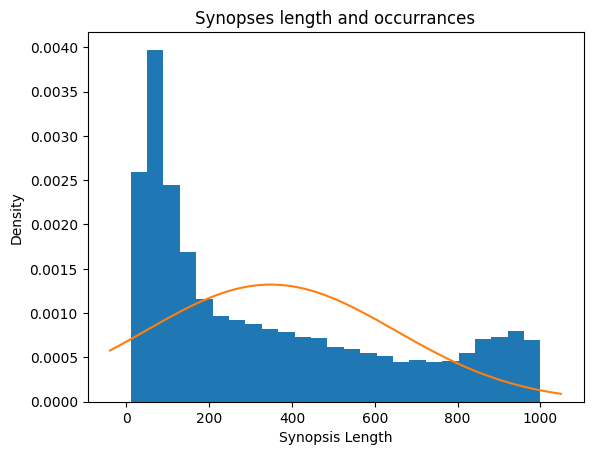

In [4]:
# Analysis of the synopsis length max-min lengths, full counts, average character lengths
import matplotlib.pyplot as mpl
from scipy.stats import norm
count = anime_df["synopsis"].count()
synopsis_count = anime_df["clean_synopsis"].count()
print(f"Number of Synopses: {synopsis_count}")
print(count)

anime_df["length"] = anime_df["clean_synopsis"].str.len()
valid = anime_df["length"].dropna()
synopsis_length_mean = np.mean(valid)
synopsis_length_max = np.max(valid)
print(F"Max Length: {synopsis_length_max}")
print(F"Mean Length: {synopsis_length_mean}")


mpl.hist(valid, bins=25, density=True)
mpl.xlabel("Synopsis Length")
mpl.ylabel("Density")
mpl.title("Synopses length and occurrances")
xmin, xmax = mpl.xlim()

mu, std = norm.fit(valid)
x = np.linspace(xmin,xmax,100)
p = norm.pdf(x,mu,std)
mpl.plot(x,p)
mpl.show()

# print(anime_df["length"].iloc[51])
# for index, clean_synopsis in anime_df["clean_synopsis"].dropna().items():
#     print(f"{index}, {clean_synopsis}")

## Find and also determine the metrics for the MLM

In [5]:
# The maximum length in BPE tokens, not characters.
# What percentage of tokens will be selected for masking.
# Whether masking will be dynamically regenerated each epoch.
# How synopses will be split into training, validation, and test sets.
# Whether each synopsis remains separate or is concatenated and chunked

from pretrained_bpe import load_bpe_tokenizer
tokenizer = load_bpe_tokenizer("data/anime_training_data/synopsis_pretrained_bpe_tokenizer")

anime_df["bpe_tokens"] = anime_df["clean_synopsis"].apply(lambda content: len(tokenizer.encode(content).tokens))

max_tokens = np.max(anime_df["bpe_tokens"])
print(f"Max BPE Tokens: {max_tokens}")
anime_df["bpe_tokens"].head(5)


Actual vocab size: 30000
Attack on Titan                → ['ĠAttack', 'Ġon', 'ĠTitan']
Tokens #: 3
Steins;Gate                    → ['ĠSte', 'ins', ';', 'G', 'ate']
Tokens #: 5
Re:Zero                        → ['ĠRe', ':', 'Zero']
Tokens #: 3
Fullmetal Alchemist            → ['ĠFull', 'met', 'al', 'ĠAlchemist']
Tokens #: 4
Max BPE Tokens: 325


0    181
1    169
2    200
3    187
4    156
Name: bpe_tokens, dtype: int64

## Data Overview
Max BPE tokens used is 325 
Dynamic masking on 15% of the training examples
80/20 training and validation split
synopses separated


In [36]:
tokens = tokenizer.encode(c_synopsis)
print(tokens)
# print(tokens.tokens)
# print(tokens.ids)
cls_id = tokenizer.token_to_id("[CLS]")
sep_id = tokenizer.token_to_id("[SEP]")
synopsis_tokens = tokens.tokens
synopsis_ids = tokens.ids
synopsis_ids = [cls_id] + synopsis_ids + [sep_id]
synopsis_tokens = ["[CLS]"] + synopsis_tokens + ["[SEP]"]
padding_tokens = ["[PAD]"] * 5
synopsis_tokens = synopsis_tokens + padding_tokens
print(synopsis_tokens)


# max_len = 170
# synopsis_ids = synopsis_ids[:max_len-2]
# print(synopsis_ids)
# mpl.hist(anime_df["bpe_tokens"], 325, density = True)
# mu, std = norm.fit(anime_df["bpe_tokens"])
# mpl.xlabel("Counts")
# mpl.ylabel("Density")
# mpl.title("BPE Token Count")
# xmin, xmax = mpl.xlim()
# x = np.linspace(xmin,xmax,100)
# p = norm.pdf(x,mu,std)
# mpl.plot(x,p)
# mpl.show()



Encoding(num_tokens=168, attributes=[ids, type_ids, tokens, offsets, attention_mask, special_tokens_mask, overflowing])
['[CLS]', 'ĠM', 'ith', 'ril', ',', 'Ġa', 'Ġcovert', 'Ġmilitary', 'Ġinstitution', 'Ġusing', 'Ġstate', '-', 'of', '-', 'the', '-', 'art', 'Ġtechnology', 'Ġto', 'Ġcombat', 'Ġterrorist', 'Ġoperations', ',', 'Ġassigns', 'Ġa', 'Ġspecialized', 'Ġteam', 'Ġto', 'Ġa', 'Ġsensitive', 'Ġmission', '.', 'ĠUnder', 'Ġthe', 'Ġcommand', 'Ġof', 'Ġsuperior', 'Ġofficer', 'ĠMelissa', 'ĠMao', ',', 'Ġser', 'ge', 'ants', 'ĠSousuke', 'ĠSagara', 'Ġand', 'ĠKur', 'z', 'ĠWe', 'ber', 'Ġmust', 'Ġsecretly', 'Ġprotect', 'ĠKaname', 'ĠChidori', 'âĢĶ', 'a', 'Ġteenage', 'Ġgirl', 'Ġwho', 'Ġunconscious', 'ly', 'Ġholds', 'Ġbreakthrough', 'Ġscientific', 'Ġknowledge', 'Ġand', 'Ġis', 'Ġconsidered', 'Ġa', 'Ġ"', 'W', 'his', 'pered', '"âĢĶ', 'from', 'Ġintelligence', 'Ġagencies', 'Ġand', 'Ġother', 'Ġorganizations', 'Ġpursuing', 'Ġher', 'Ġabilities', '.', 'ĠWhile', 'ĠKur', 'z', 'Ġand', 'ĠMelissa', 'Ġare', 'Ġto', 'Ġas